## Document-term matrix
* Organize data into a document term matrix (DTM) format. 
* Excluding common English stopwords.

In [5]:
import pandas as pd

df = pd.read_csv("cleaned_yt_comments.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11151 entries, 0 to 11150
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   video_id                   11151 non-null  object
 1   view_count                 11151 non-null  int64 
 2   title                      11151 non-null  object
 3   video_date                 11151 non-null  object
 4   video_description          11151 non-null  object
 5   channel_name               11151 non-null  object
 6   comment_id                 11151 non-null  object
 7   comment_text               11149 non-null  object
 8   comment_author_name        11151 non-null  object
 9   comment_author_channel_id  11151 non-null  object
 10  comment_date               11151 non-null  object
 11  comment_likes              11151 non-null  int64 
 12  comment_reply_count        11151 non-null  int64 
dtypes: int64(3), object(10)
memory usage: 1.1+ MB


In [6]:
df = df.dropna(subset=['comment_text']).copy()
df.head()

,video_id,view_count,title,video_date,video_description,channel_name,comment_id,comment_text,comment_author_name,comment_author_channel_id,comment_date,comment_likes,comment_reply_count
0,u-E2O-aMdSY,14076,Minneapolis Mayor says ICE agents leaving 'is ...,2026-02-05 01:48:33+00:00,CNN's Kasie Hunt spoke with Minneapolis Mayor ...,CNN,UgyNjKdvC4Xyk8zYl5h4AaABAg,They are regrouping.,@D_fen,UC2u_Dx5Tu64IViTSY1VInzA,2026-02-05 01:52:28+00:00,38,1
1,u-E2O-aMdSY,14076,Minneapolis Mayor says ICE agents leaving 'is ...,2026-02-05 01:48:33+00:00,CNN's Kasie Hunt spoke with Minneapolis Mayor ...,CNN,UgxS4uoWMM_-Yt5vHI94AaABAg,If you don't call removing the 700 agents a de...,@dogrsqr,UC43hAYxNIxNfI-HUCxn7XUg,2026-02-05 02:11:20+00:00,23,2
2,u-E2O-aMdSY,14076,Minneapolis Mayor says ICE agents leaving 'is ...,2026-02-05 01:48:33+00:00,CNN's Kasie Hunt spoke with Minneapolis Mayor ...,CNN,UgyzTnAwMsoPPfcHIwJ4AaABAg,"I agree, this is not de escalation when those ...",@laurasalazar5728,UC9_RKs37YKvnZww7nbLNmEA,2026-02-05 02:23:33+00:00,7,0
3,u-E2O-aMdSY,14076,Minneapolis Mayor says ICE agents leaving 'is ...,2026-02-05 01:48:33+00:00,CNN's Kasie Hunt spoke with Minneapolis Mayor ...,CNN,UgzT2yeuJwtJMEd3-V54AaABAg,"No, they're just flipping them out because the...",@mafa7538,UCGsM-kCOMJ3tG4WZWWBxtpA,2026-02-05 01:59:32+00:00,17,2
4,u-E2O-aMdSY,14076,Minneapolis Mayor says ICE agents leaving 'is ...,2026-02-05 01:48:33+00:00,CNN's Kasie Hunt spoke with Minneapolis Mayor ...,CNN,Ugw2yQwJsfRDoOyqO5Z4AaABAg,"Instead of four agents to a car, there will be...",@arnoldwillis7685,UCkK5iC-2xNF7oh3Vp3wRGiQ,2026-02-05 03:19:42+00:00,2,0


**NOTE**: For sentiment analysis TweetTokenizer was used, but for topic modeling I'm trying out spacy with lemmatization which may be more helpful for building a cohesive DTM.

In [8]:
!pip install spacy

  Using cached spacy-3.8.11-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (27 kB)
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached murmurhash-1.0.15-cp313-cp313-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (2.3 kB)
  Using cached cymem-2.0.13-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (9.7 kB)
  Using cached preshed-3.0.12-cp313-cp313-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (2.5 kB)
  Using cached thinc-8.3.10-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (15 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached srsly-2.5.2-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (19 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached wea

In [9]:
# download a model for english
!python3 -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 98.8 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [10]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [17]:
import re

def spacy_lemmatizer(text):
    # extra clean step to filter out non-alphabetical symbols: -, ., $, +, numbers
    clean_text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    doc = nlp(clean_text)
    tokens = [token.lemma_.lower() for token in doc if len(token.lemma_) > 1 and not token.is_space and not token.is_stop]
    return tokens

In [18]:
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import CountVectorizer

# Build DTM with lemmatization and no stopwords
cv = CountVectorizer(tokenizer=spacy_lemmatizer, token_pattern=None)
data_cv = cv.fit_transform(df['comment_text'])
dtm_df = pd.DataFrame(data_cv.toarray(), columns=cv.get_feature_names_out(), index=df.index)

In [21]:
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_colwidth', None)
pd.reset_option('display.max_columns')

In [22]:
dtm_df.head()

,aa,aaaagh,abandon,abc,abduct,abe,abet,abetting,abide,ability,...,yuk,yup,zable,zach,zero,zoe,zom,zombie,zombifie,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Top 30 most common words

**Preliminary observations**

* "don": may be from tokenizing "don't" into "don" and "t" and may need to be included as stopword.
* we see legal terms like "arrest", "law", "criminal", "federal", "jail", "charge" indicating a lot of legal and may be accountability/criminality debate surrounding ICE protests.
* some positive and patriotism/nationalism-related terms like "thank", "like", "country", "america", which I found many comments of this sentiment on Fox News videos (e.g. "thank you officers", "thank Tom Holman").
* the term "good" can either mean the adjective as in "good job" (we do also see "job" in the list) or referring to a prominent victim of ICE agents violence on Renee Good (?) (may be less likely since there is no term for "Renee")
* prominent actors/people terms present: "ice", "agent", "mayor", "protester" that can be inferred the people at the focus of this topic's debate.

In [23]:
word_frequencies = dtm_df.sum(axis=0)
top_30_words = word_frequencies.sort_values(ascending=False).head(30)

print(top_30_words)

people       1191
arrest       1061
ice          1044
need          833
law           742
don           526
like          512
protest       493
thank         490
go            435
mayor         379
agent         379
time          369
stop          360
criminal      358
federal       349
want          347
jail          345
good          312
know          310
pay           305
country       303
protester     299
right         280
america       274
get           268
say           264
job           262
charge        256
state         255
dtype: int64


## Visualize the data

* **Qualitative/Question 1:** I want to see how top common words differ between CNN and Fox News. Since Fox News videos dominate the volume of this dataset (there are 291 related Fox News videos but only 81 videos from CNN), breaking this up into 2 channels can let us visualize the granular differences between each channel.

(code below)

In [34]:
dtm_df['channel_name'] = df['channel_name']
channel_freq = dtm_df.groupby('channel_name').sum()

cnn_top = channel_freq.loc['CNN'].sort_values(ascending=False).head(20)
fox_top = channel_freq.loc['Fox News'].sort_values(ascending=False).head(20)

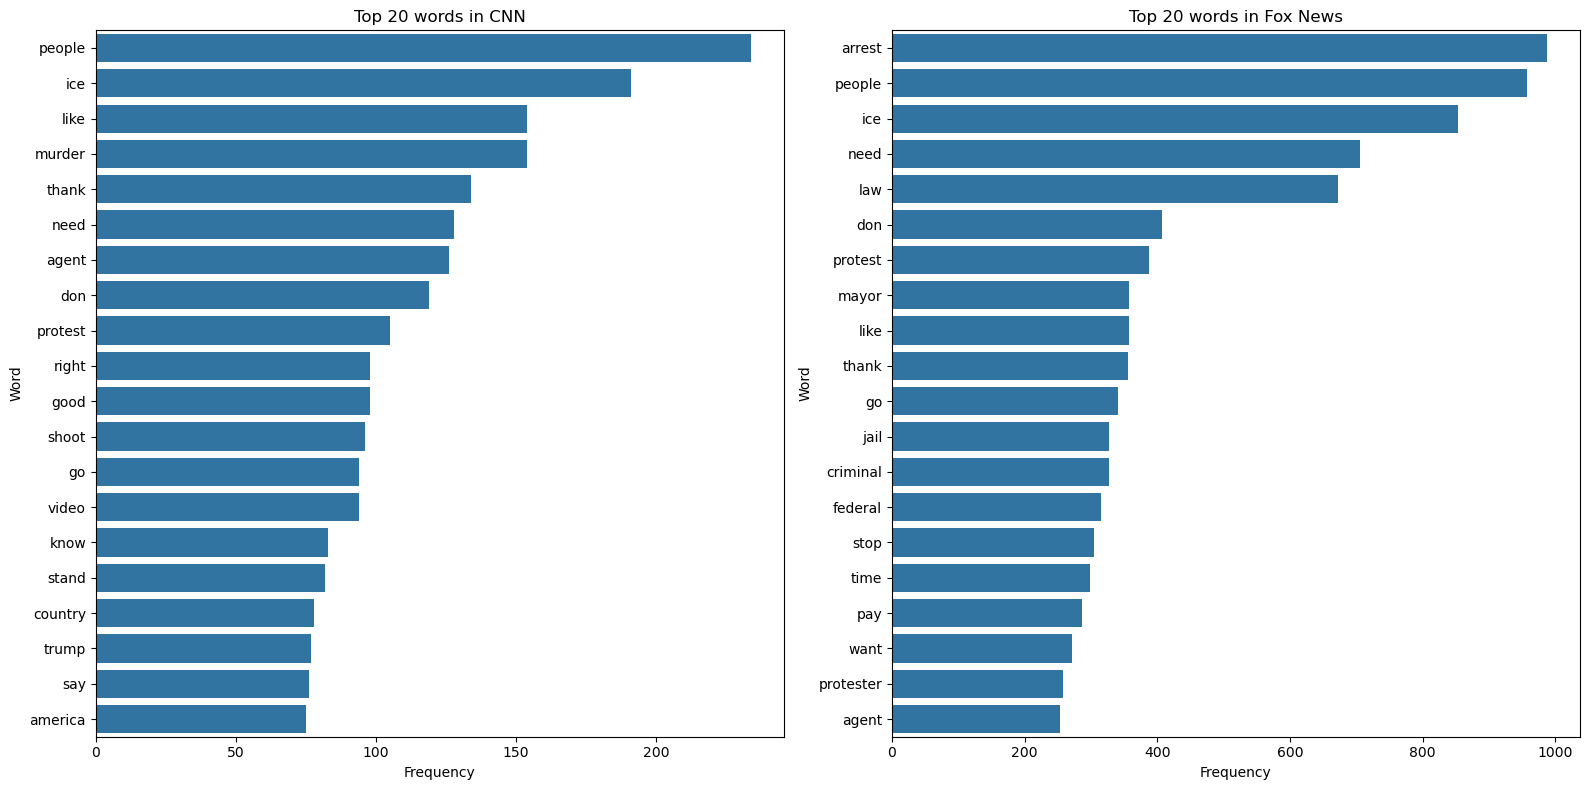

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x=cnn_top.values, y=cnn_top.index, ax=axes[0])
axes[0].set_title('Top 20 words in CNN')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Word')

sns.barplot(x=fox_top.values, y=fox_top.index, ax=axes[1])
axes[1].set_title('Top 20 words in Fox News')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Word')

plt.tight_layout()
plt.show()

In [45]:
cnn = df[df["channel_name"] == "CNN"]
fox = df[df["channel_name"] == "Fox News"]

len(cnn["title"].unique())

81

In [46]:
len(fox["title"].unique())

291

**Inference 1:** Some shared common terms as well as differences between CNN and Fox News comments

* CNN commentors feel very strongly about violence. Terms like "murder" and "shoot" are absent in Fox News but appear at the top here aligns with my expectation that left-leaning discussing the physical actions and consequences of the ICE agents. "good" also appears at the top without the word "job", so I figured it was more likely referring to "Renee Good" than the adjective compliment "good job".

* For Fox, I was surprised to see "arrest" at the top, but figured the conservative audience are focused on arrests of illegal immigrants, the main narrative in conservative channels. Many other "law and order" terminology also appears at the top here like "law", "jail", "criminal", and federal shows their views leaning towards criminality rather than civil rights or social movement, compared to top words of "protest" in CNN.

* A limitation to note is not being able to tell the context with single words frequencies. Such as the term "thank" is present in both channels, but one might be more sarcastic or referring to very different parties/people, but we are unable to tell that definitively.

**Qualitative/question 2:** I also want to break down top words for only the most highly endorsed (liked) comments for each channels and see if their top vocabulary reflect the same as the general comment pool. I will thus slice the data by the 90th percentile of most liked comments in each channel, get the top 20 common words for visualization.

(code below)

In [52]:
dtm_df['comment_likes'] = df['comment_likes'].values

def get_top_liked_words(channel_name, n_words=20):
    channel_data = dtm_df[dtm_df['channel_name'] == channel_name]
    thres = channel_data['comment_likes'].quantile(0.90)
    top_liked_comments = channel_data[channel_data['comment_likes'] >= thres]
    word_df = top_liked_comments.drop(columns=['channel_name', 'comment_likes']).copy()
    return word_df.sum().sort_values(ascending=False).head(n_words)

In [53]:
cnn_top_liked = get_top_liked_words('CNN', 20)
fox_top_liked = get_top_liked_words('Fox News', 20)

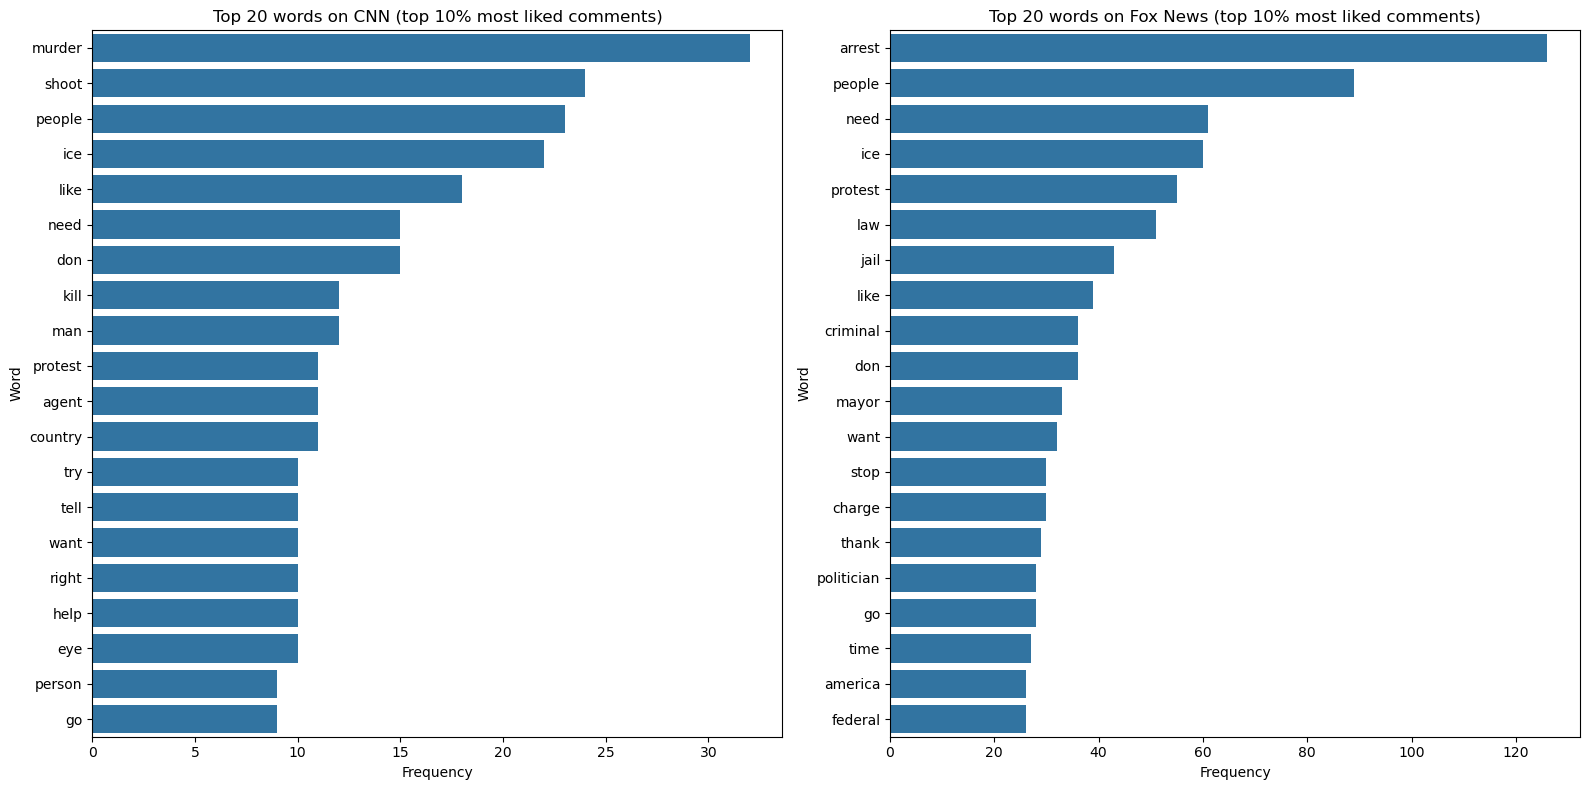

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x=cnn_top_liked.values, y=cnn_top_liked.index, ax=axes[0])
axes[0].set_title('Top 20 words on CNN (top 10% most liked comments)')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Word')

sns.barplot(x=fox_top_liked.values, y=fox_top_liked.index, ax=axes[1])
axes[1].set_title('Top 20 words on Fox News (top 10% most liked comments)')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Word')

plt.tight_layout()
plt.show()

**Inference 2**:

* We see more clearly in CNN top liked comments, violence plays even a bigger focus in the debate compared to the general pool, with "murder", "shoot", "kill" at the top of the list.
* In CNN, "help" and "eye" keywords remind me of Alex Pretti's incidents, where many commentors mention he was "trying to help" another female protestor before being killed by ICE agents, as well as comments like "they look him in the eye and murder him". This _might_ indicate top liked comments are also from videos about specific violent incidents of ICE agents on protestors.
* No real change in Fox News top liked comments vs the general pool, indicating the law and order views are equally shared, widely spread with little nuance/extremity in their sentiment.

## Profanity

* Using LIWC "swear" words to define and detect profanity. I aim to visualize again if there's difference in profanity used in CNN vs Fox, and output the number of profanity used in the general comments pool as well.

(code below)

In [80]:
liwc_dict = pd.read_csv("LIWC2015.csv")

In [63]:
profanity = liwc_dict["121\nSwear"]
profanity = profanity.dropna()

In [73]:
regex_terms = [word.replace('*', '.*') for word in profanity]

profane_columns = []
for col in dtm_df.columns:
    for pattern in regex_terms:
        if re.match(f'^{pattern}$', col):
            profane_columns.append(col)
            break

dtm_profanity = dtm_df[profane_columns].copy()

In [74]:
profanity_count = dtm_profanity.sum().sort_values(ascending=False)
print(profanity_count)

idiot        141
hell          76
crap          46
bs            42
moron         25
dumb          23
fuck          18
shit          16
wtf           15
ass           14
freak         12
lmao          11
idiotic        8
heck           8
suck           8
damn           8
asshole        6
butt           5
dumber         5
dummy          5
piss           4
bullshit       4
jackass        4
freaking       4
lmfao          3
bitch          3
bastard        3
af             3
fucking        3
screw          3
effing         2
bloody         2
dumbass        2
freakin        2
prickster      2
dork           2
dammit         2
damned         2
effin          2
dang           1
damnit         1
crappy         1
arse           1
ignoramus      1
goddamn        1
frigging       1
friggin        1
pricktzer      1
moronic        1
lmaooooo       1
lmaooo         1
screwy         1
screwball      1
stfu           1
shitter        1
dtype: int64


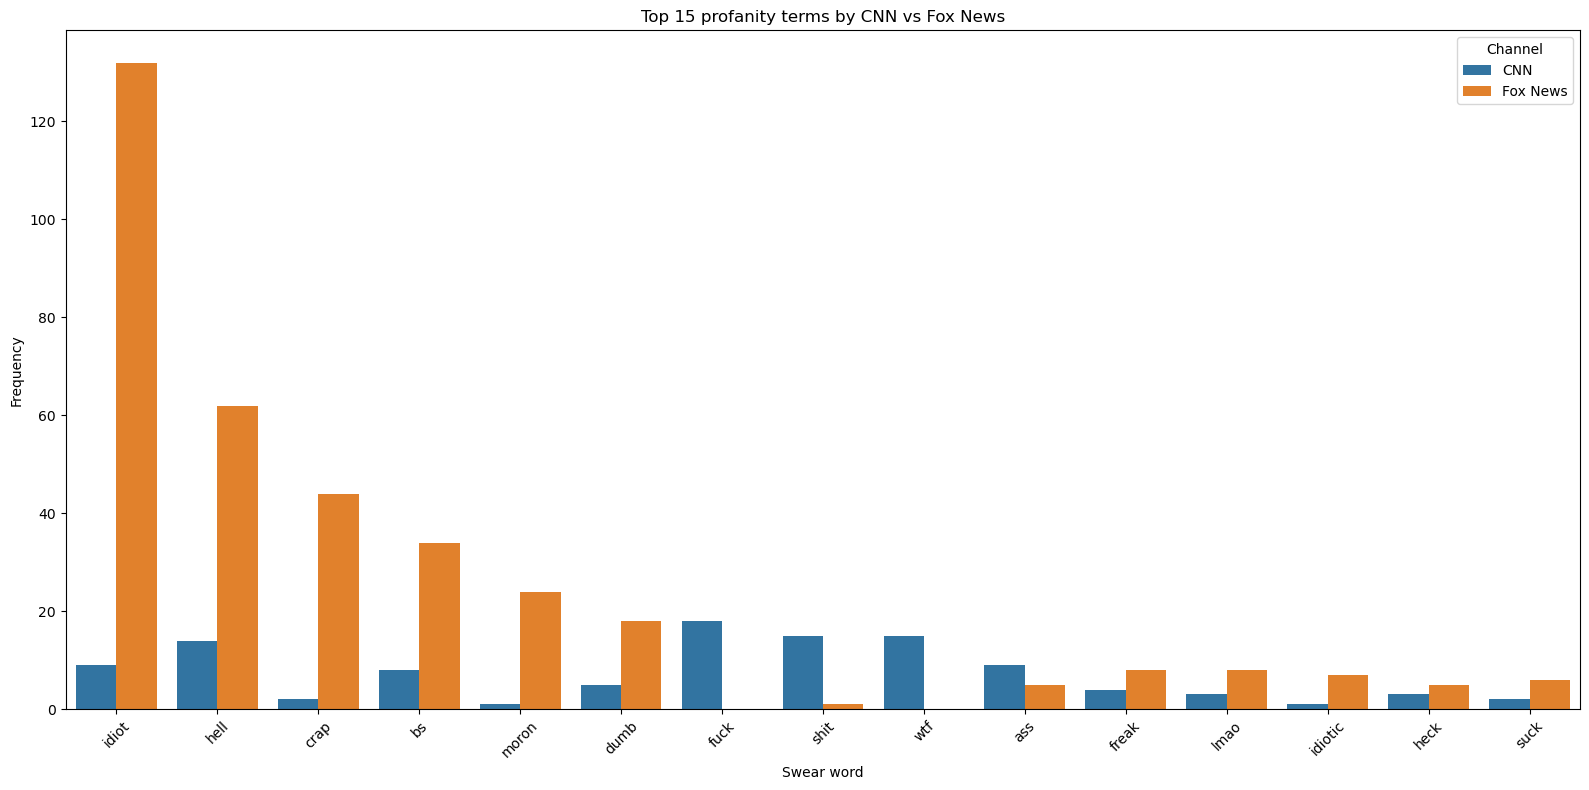

In [79]:
dtm_profanity['channel_name'] = df['channel_name'].values
sw_freq_channel = dtm_profanity.groupby('channel_name').sum()
top_15_sw = sw_freq_channel.sum().sort_values(ascending=False).head(15).index
melted_profanity = sw_freq_channel[top_15_sw].reset_index().melt(
    id_vars='channel_name',
    var_name='Swear word',
    value_name='Frequency')

plt.figure(figsize=(16, 8))
sns.barplot(data=melted_profanity, x='Swear word', y='Frequency', hue='channel_name')

plt.title('Top 15 profanity terms by CNN vs Fox News')
plt.ylabel('Frequency')
plt.xlabel('Swear word')
plt.xticks(rotation=45)
plt.legend(title='Channel')

plt.tight_layout()
plt.show()

**Inference:**

* In general pool, at the top most common swear word used is "idiot".
* One thing to note is because our methods use LIWC, which is formal english words, and match against cleaned, lemmatized tokens from comments_text, we might have missed many profanity variations in social media that includes symbols like "f\*ck", "sh\*t".
* When broken down by news channels, even though by volume, Fox News seems to use much more profanity than CNN, but this is partly due to our data corpus asymmetrically include more Fox videos than CNN's.
* In terms of specific term use, CNN is much more inclined to use "fuck" and "shit" and "wtf" (used more often by a younger audience?), compared to top terms of "idiot", "hell", "crap", "bs", and "dumb" in Fox News comments (swear words to insult cognitive abilities and used in older generations).

## Topic modeling

I'm running topic modeling using gensim and LDA on the lemmatized and cleaned data. Some considerations before running:

* Using CountVectorizer parameters to filter out corpus stopwords (choosing max_df=0.9, min_df=5, for stop word that exists more than 90% in corpus and appear in <5 comments like typos or unique names).
* Because gensim requires a TDM instead of DTM, I will transpose my exisitin dtm_df before converting it to gensim corpus.
* I'll set the number of topics to 4 and passes to 10. Given the narrow focus of the dataset topic of ICE protests, a lower topic count would be more appropriate and prevent unintelligible, messy micro-topics and redundancy.

(code below)

In [81]:
!pip install gensim

  Using cached gensim-4.4.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (8.4 kB)
Using cached gensim-4.4.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (27.8 MB)


In [83]:
import scipy.sparse
from gensim import matutils, models
from sklearn.decomposition import LatentDirichletAllocation

cv_lda = CountVectorizer(tokenizer=spacy_lemmatizer, token_pattern=None, max_df=0.9, min_df=5)
dtm_lda = cv_lda.fit_transform(df['comment_text'])

tdm_sparse = dtm_lda.transpose()
sparse_counts = scipy.sparse.csr_matrix(tdm_sparse)
corpus = matutils.Sparse2Corpus(sparse_counts)

id2word = dict((v, k) for k, v in cv_lda.vocabulary_.items())

lda_model = models.LdaModel(corpus=corpus, id2word=id2word, num_topics=4, passes=10, random_state=95)

topics = lda_model.print_topics(num_words=10)
for topic in topics:
    print(f"Topic {topic[0] + 1}: {topic[1]}\n")

Topic 1: 0.023*"like" + 0.021*"law" + 0.015*"officer" + 0.015*"ice" + 0.013*"look" + 0.013*"protester" + 0.012*"agent" + 0.012*"federal" + 0.011*"stop" + 0.011*"go"

Topic 2: 0.075*"arrest" + 0.040*"need" + 0.032*"people" + 0.029*"jail" + 0.025*"protest" + 0.023*"criminal" + 0.020*"charge" + 0.018*"time" + 0.013*"hold" + 0.013*"stop"

Topic 3: 0.051*"ice" + 0.035*"thank" + 0.025*"country" + 0.019*"job" + 0.017*"good" + 0.017*"god" + 0.017*"america" + 0.017*"american" + 0.014*"trump" + 0.014*"deport"

Topic 4: 0.032*"law" + 0.028*"mayor" + 0.022*"people" + 0.020*"don" + 0.016*"need" + 0.015*"governor" + 0.015*"pay" + 0.015*"state" + 0.014*"city" + 0.014*"vote"



**Inference:**

* We get pretty good 4 distinct topics very relevant to our observations from visualization of top keywords in Q2 above.
* Topic 1: maybe related to **interations between officer/agents and protestors** (?) with keywords like "officer", "protester", "agent", "stop", "look", "go".
* Topic 2: related to the **"law and order"** sentiment seen in Q2 and viewing ICE protests not as civil demonstrations, but heavily focused on criminal behavior and demanding legal consequences/accountability. Keywords are "arrest", "jail", "criminal", "charge", "stop".
* Topic 3: related to **nationalism**, with words like praising "thank", "good", "job", "god" and nationalistic terms "america", "country", "trump", "deport". This topic seems heavily distributed among conservative audience validating ICE's mission, American patriotism and Trump leadership.
* Topic 4: related to **local politics and accountability** with words like "mayor", "govenor", "pay", "state", "city", "vote". This topic sheds light on one of the topics at the focus of ICE protest is not only about the demonstration itself but also demand to local political leadership around taxpayer frustration and voting calls.

## Additional questions - Bigrams and Knowledge Graph

**Qualitative:** I've already analyzed unigram (single-word) frequency and topic modeling, but realized the key limitation of unigram is lack of context like "thank" or "good" mentioned above. I wanted to do another analysis for top keywords and topics using n_grams of 2, see if we're able to get any new information in addition to above.


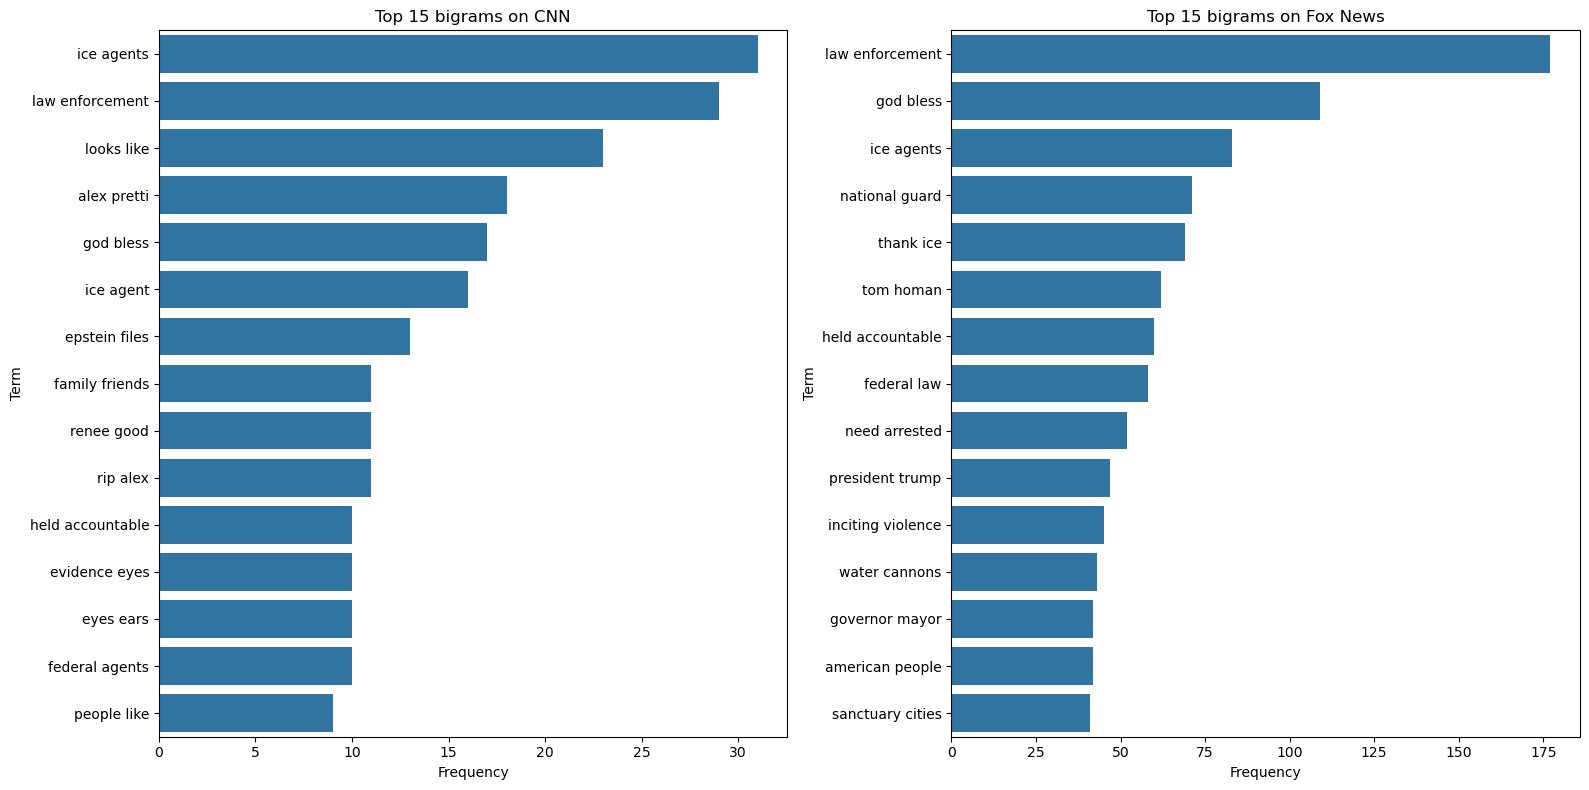

In [85]:
cv2 = CountVectorizer(ngram_range=(2, 2), stop_words='english', min_df=3)
data_bigram = cv2.fit_transform(df['comment_text'])

dtm_bigram = pd.DataFrame(data_bigram.toarray(), columns=cv2.get_feature_names_out())
dtm_bigram['channel_name'] = df['channel_name'].values

bigram_freq_channel = dtm_bigram.groupby('channel_name').sum()
cnn_top_bigrams = bigram_freq_channel.loc['CNN'].sort_values(ascending=False).head(15)
fox_top_bigrams = bigram_freq_channel.loc['Fox News'].sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.barplot(x=cnn_top_bigrams.values, y=cnn_top_bigrams.index, ax=axes[0])
axes[0].set_title('Top 15 bigrams on CNN')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Term')

sns.barplot(x=fox_top_bigrams.values, y=fox_top_bigrams.index, ax=axes[1])
axes[1].set_title('Top 15 bigrams on Fox News')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Term')

plt.tight_layout()
plt.show()

**Inference**: With bigrams it was much easier to see the context and meanings of the words. We are able to get new insights using bigrams, which share some common theme with unigrams but also some key differences.

* Common theme with Q2 before: the core events and mentions of "ice agents" and "law enforcement".

* Unsure if this difference is significant or not, but there is more use of official word like "law enforcement", "national guard" to refer to ICE agents in Fox News channels (almost doubled in frequency of use for "law enforcement" compared to "ice agents" in right graph), while we see an equal use of "ice agents" and "law enforcement" in CNN. The official language use in right-wing media may hint at the narrative in conservative news in seeing the actions of ICE as legitimate lawful acts, compared to more controversial views of them as illegal federal agents arrests on the left side.

* We see more clearly here Fox news focus on nationalism with terms like "god bless", "thank ice", "tom holman".

* Meanwhile, CNN sentiment focuses on cases of victims of ICE agents' violence like Alex Pretti, Renee Good (which we can now clearly have evidence for the context of the term "good" in unigram graph above). It also emphasizes the confrontation of violence with calls for evidence of eyes and ears.


**Qualitative 2:** With the available bigrams, I also think it's interesting to see if we can construct a network graph to how each word in bigrams are used, e.g. "mayor" linked to "democrats", "idiot", "arrest" or something like that.

I will use networkx library to visualize this and convert the top 40 bigrams for each channel into an undirected graph. Structure of graph:

* Nodes: individual words from the bigrams; size of node will be scaled based on its how many other words it connects to.

* Edges: thickness of the line will be scaled based on the raw frequency of that bigram in the dataset.

Reason: bar chart only isolates phrases while a network graph connects them and help show words like "mayor" as a central hub with "frey" and "corrupt" branching off of it, showing the associative logic of the audience.


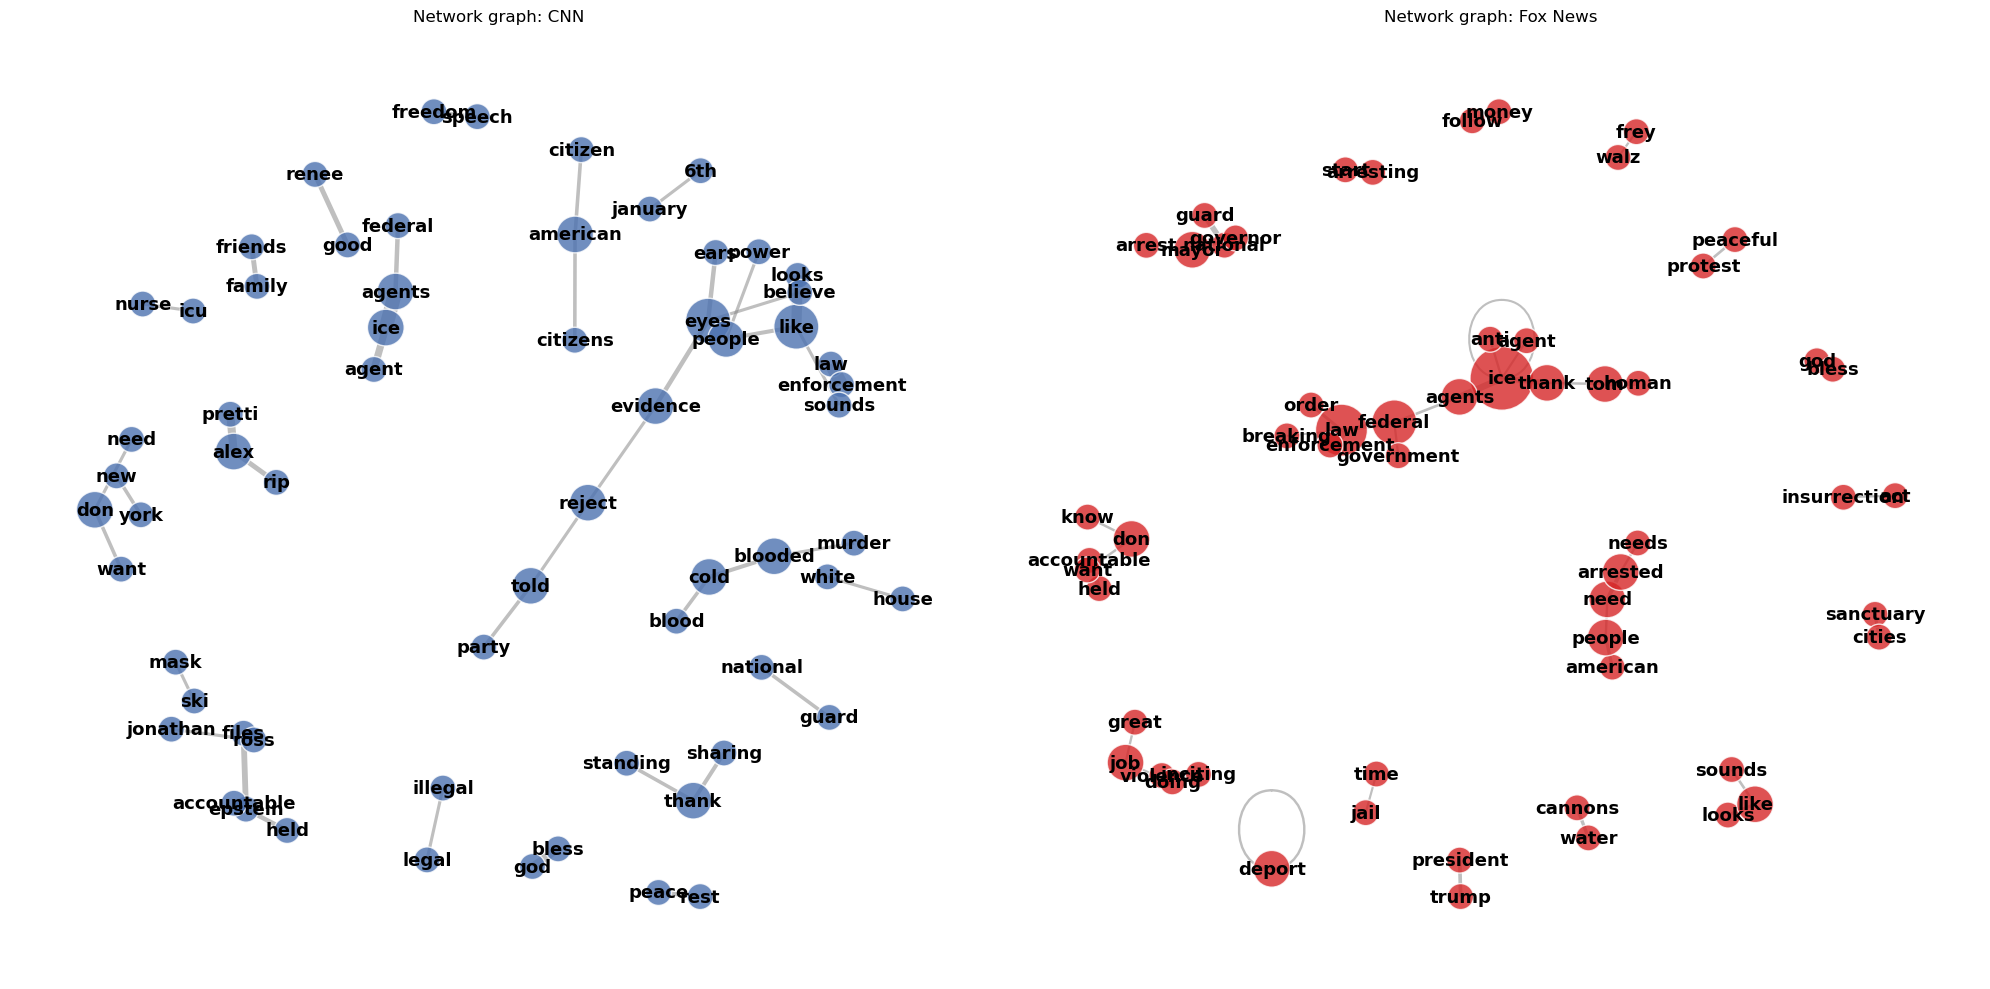

In [88]:
import networkx as nx

def build_and_plot_network(bigram_series, channel_name, ax, node_color):
    G = nx.Graph()
    top_bigrams = bigram_series.sort_values(ascending=False).head(40)

    for bigram, freq in top_bigrams.items():
        words = bigram.split()
        if len(words) == 2:
            G.add_edge(words[0], words[1], weight=freq)
    
    pos = nx.spring_layout(G, k=0.60, iterations=50, seed=95) 
    node_sizes = [dict(G.degree)[node] * 350 for node in G.nodes()]
    edge_widths = [G[u][v]['weight']/(top_bigrams.max()*0.1) for u, v in G.edges()]
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_color, node_size=node_sizes, alpha=0.8, edgecolors='white')
    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, alpha=0.5, edge_color='gray')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=13, font_weight='bold')
    
    ax.set_title(f'Network graph: {channel_name}')
    ax.axis('off')


fig, axes = plt.subplots(1, 2, figsize=(20, 10))
build_and_plot_network(bigram_freq_channel.loc['CNN'], 'CNN', axes[0], '#4c72b0') # blue
build_and_plot_network(bigram_freq_channel.loc['Fox News'], 'Fox News', axes[1], '#d62728') # red

plt.tight_layout()
plt.show()

**Inference 2**:

* On the spot, we see Fox News network is more clustered with a big central cluster for "breaking law", "thank ice", and "anti ICE". In this spring_layout we choose, the physical centralization of the "ice" and "agents" cluster indicates it is the most highly connected, unified node (and potentially echo chambers?) in the network.
* The CNN graph is much more fractured into many smaller, disconnected clusters, with no single dominant/rallying hub that connects the whole comment section together.
* CNN graph also have terms in longer string/chain form instead of tight clusters like in Fox, indicating CNN comments are formed with more complex, multi-word sentences rather than repeating a single, unified rallying cry.